# Gas-class classification under sensor drift

**Task.** Identify which of 6 gases produced each measurement in batch 10, from 128 sensor
features. Metric: macro-F1. Training data covers batches 1-9; batch 10 is held out.

**The problem in one line.** The 16 sensors drift between batches, so a model fitted on
batches 1-9 must classify measurements whose feature distribution has moved. Everything
below is organised around that.

**What we submitted.** `lda_tuned.csv` - LDA with Ledoit-Wolf shrinkage on 145 engineered
features, per-batch mean centring to remove drift, then confidence-ranked self-training on
the unlabelled test batch.

| model | file | validation (§8.1) | leaderboard |
|---|---|---|---|
| LDA + Ledoit-Wolf, uncentred | `lda_lw.csv` | 0.934 | 0.870 |
| QDA, `reg_param=0.3` | `qda.csv` | 0.814 | 0.670 |
| LDA + per-batch centring | `lda_centered.csv` | 0.935 | 0.901 |
| **+ self-training (final)** | **`lda_tuned.csv`** | **0.982** | - |

Validation is the mean over held-out batches 7, 8 and 9 under the expanding-window protocol
of §8. Sections 1-7 are the modelling narrative in the order we worked; §8-§10 are the
validation, ablations and diagnostics that justify the choices made in them.

*Reproducibility: run top to bottom from the `notebook/` directory. Every step in the final
pipeline is deterministic - no random seeds are involved.*

In [1]:
import numpy as np
import pandas as pd
import os, json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report


## 1. Imports and data

### Loading

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
train.head()

,measurement_id,batch,gas_class,concentration,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,...,feat_119,feat_120,feat_121,feat_122,feat_123,feat_124,feat_125,feat_126,feat_127,feat_128
0,G_B01_0001,1,1,10.0,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,G_B01_0002,1,1,20.0,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,...,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,G_B01_0003,1,1,30.0,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,...,-2.384784,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370
3,G_B01_0004,1,1,40.0,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957
4,G_B01_0005,1,1,50.0,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


In [3]:
FEATS_ALL = [f"feat_{i}" for i in range(1, 129)]     # the 128 raw sensor columns
print(f"{len(FEATS_ALL)} features | train {train.shape} | test {test.shape}")
print("columns in train but not test:", sorted(set(train.columns) - set(test.columns)))
print("train batches:", sorted(train.batch.unique()), "| test batches:", sorted(test.batch.unique()))

128 features | train (10310, 132) | test (3600, 131)
columns in train but not test: ['gas_class']
train batches: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)] | test batches: [np.int64(10)]


## cleaning

In [4]:
print(train.shape)
print("missing:", train.isna().sum().sum())
print("duplicates:", train.duplicated().sum())
train.describe().T

(10310, 132)
missing: 0
duplicates: 0


,count,mean,std,min,25%,50%,75%,max
batch,10310.0,5.333948,2.215240,1.000000,3.000000,6.000000,7.000000,9.000000
gas_class,10310.0,3.348885,1.734096,1.000000,2.000000,3.000000,5.000000,6.000000
concentration,10310.0,127.777546,98.391406,1.000000,50.000000,100.000000,200.000000,1000.000000
feat_1,10310.0,52497.694168,73580.146804,-16757.598600,6790.232825,17761.435350,68616.536400,670687.347700
feat_2,10310.0,6.958188,15.391388,0.088287,2.364660,3.845847,8.558739,1339.879283
...,...,...,...,...,...,...,...,...
feat_124,10310.0,16.107592,12.937726,0.011488,5.867924,12.576534,22.809851,297.225880
feat_125,10310.0,20.120112,14.984227,0.118849,8.199157,15.760582,28.339368,195.242555
feat_126,10310.0,-5.065968,3.423435,-26.038724,-7.412720,-4.291343,-2.179399,-0.003817
feat_127,10310.0,-8.211546,5.922605,-56.133676,-11.924288,-6.816722,-3.458417,6.851792


### 1.1 Class balance and batch composition

`describe()` says nothing about the two things that actually shape this problem: how the
classes are distributed, and how unevenly they are spread across batches.

In [5]:
display(pd.crosstab(train.batch, train.gas_class, margins=True, margins_name="all"))

counts = train.gas_class.value_counts().sort_index()
print(f"overall imbalance {counts.max()/counts.min():.2f}:1  "
      f"(smallest class {counts.min()}, largest {counts.max()})")
for b in sorted(train.batch.unique()):
    d = train[train.batch == b].gas_class.value_counts()
    gone = [k for k in range(1, 7) if d.get(k, 0) < 5]
    if gone:
        print(f"  batch {b}: class {gone} effectively absent (n = {[int(d.get(k, 0)) for k in gone]})")

gas_class,1,2,3,4,5,6,all
batch,,,,,,,
1,90,98,83,30,70,74,445
2,164,334,100,109,532,5,1244
3,365,490,216,240,275,0,1586
4,64,43,12,30,12,0,161
5,28,40,20,46,63,0,197
6,514,574,110,29,606,467,2300
7,649,662,360,744,630,568,3613
8,30,30,40,33,143,18,294
9,61,55,100,75,78,101,470


overall imbalance 2.31:1  (smallest class 1041, largest 2409)
  batch 3: class [6] effectively absent (n = [0])
  batch 4: class [6] effectively absent (n = [0])
  batch 5: class [6] effectively absent (n = [0])


Two separate facts here, and the second is the one that matters.

*Overall* the classes are only mildly imbalanced - 2.31:1 between largest and smallest - so
we do not need resampling or class weights.

*Per batch* the composition is wildly uneven. Batches 3, 4 and 5 contain **no class-6
measurements at all**, and batch 2 contains five. The batches are therefore not
interchangeable samples from one distribution; they differ in which gases were even measured.

This has a direct consequence for the drift correction in §6. Any correction that works by
subtracting a per-batch summary statistic has to cope with the fact that a plain mean of a
batch missing an entire class is not measuring the same quantity as the plain mean of a
complete batch. That is why we centre with a *class-balanced* mean rather than a plain one -
and it is an assumption we test directly in §8.3.

### 1.2 Heavy tails

`feat_1` runs to 670,687 while `feat_128` reaches -410. Before deciding how to handle that,
it is worth checking whether these are errors to remove or simply the scale the sensors
work on.

In [6]:
_A = train[FEATS_ALL].to_numpy()
_slog = lambda x: np.sign(x) * np.log1p(np.abs(x))

def tail_summary(M, name):
    z = (M - M.mean(0)) / M.std(0)
    print(f"{name:11s} max|value| = {np.abs(M).max():>10.1f}   "
          f"|z|>10: {(np.abs(z) > 10).mean():.5f}   mean skew = {pd.DataFrame(M).skew().mean():>6.2f}")

tail_summary(_A, "raw")
tail_summary(_slog(_A), "signed log")

raw         max|value| =   670687.3   |z|>10: 0.00025   mean skew =   3.73

signed log  max|value| =       13.4   |z|>10: 0.00019   mean skew =  -0.59


The extremes are not data errors - they are the high-concentration end of a sensor response
spanning five orders of magnitude, and the same measurements appear in the test set. Deleting
or winsorising them would throw away real signal.

The signed log `sign(x) * log1p(|x|)` handles this without discarding anything: mean skew
falls from 3.7 to -0.59 and the range compresses to a usable one, while sign is preserved
(many features are legitimately negative) and 0 maps to 0. We use it on every feature block
from here on.

Note it barely changes the *fraction* of extreme points. That is the intent - we are fixing
the scale, not removing observations.

### 1.3 How much drift is there, and what shape is it?

The data overview confirms sensor drift. Before building a correction we want to know whether
drift is a steady trend across batches - in which case reaching batch 10 is a forecasting
problem - or an unpredictable per-batch offset, which needs a completely different fix.

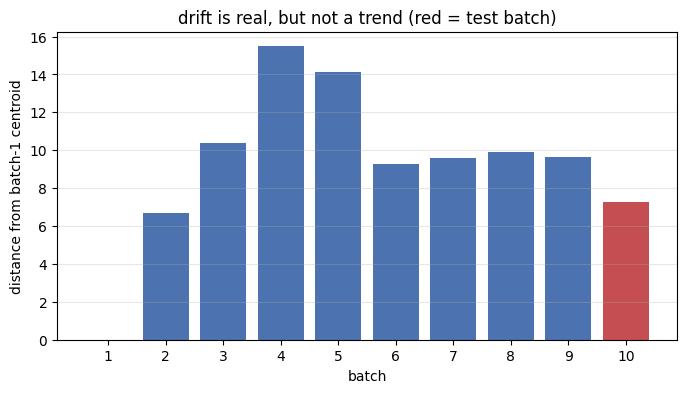

{1: 0.0, 2: 6.69, 3: 10.38, 4: 15.48, 5: 14.14, 6: 9.29, 7: 9.58, 8: 9.91, 9: 9.66, 10: 7.28}


In [7]:
_Z = _slog(train[FEATS_ALL].to_numpy())
_mu, _sd = _Z.mean(0), _Z.std(0)
_Zs = (_Z - _mu) / _sd
_Zt = (_slog(test[FEATS_ALL].to_numpy()) - _mu) / _sd        # test standardised on TRAIN stats

_bt = train.batch.to_numpy()
_ref = _Zs[_bt == 1].mean(0)
drift = {int(b): np.linalg.norm(_Zs[_bt == b].mean(0) - _ref) for b in sorted(train.batch.unique())}
drift[10] = np.linalg.norm(_Zt.mean(0) - _ref)

fig, ax = plt.subplots(figsize=(8, 4))
ks = sorted(drift)
ax.bar(ks, [drift[k] for k in ks], color=["#4C72B0"] * 9 + ["#C44E52"])
ax.set_xlabel("batch"); ax.set_ylabel("distance from batch-1 centroid")
ax.set_title("drift is real, but not a trend (red = test batch)")
ax.set_xticks(ks); ax.grid(alpha=.3, axis="y")
plt.show()
print({k: round(float(v), 2) for k, v in drift.items()})

This rules out the forecasting framing. If drift were a steady trend, distance from batch 1
would climb with batch number. Instead batches 4 and 5 are the *most* displaced (15.5, 14.1),
batches 6-9 sit back around 9-10, and the test batch is at 7.3 - closer to batch 1 than
batches 3 through 9 are.

So there is no trend to extrapolate. Each batch carries its own largely independent offset.
That is the argument for the correction in §6: estimate and remove a per-batch offset,
rather than modelling drift as a function of batch number.

It also predicts something we can check later - batch 10 should not be unusually hard just
because it comes last. The leaderboard scores do land close to the batch-9 validation scores,
which is consistent with this.

### 1.4 Concentration

`concentration` is supplied for both train and test, so it is a legitimate feature. The
question is how much it carries alone - a variable that nearly determines the class would
make the rest of the pipeline mostly decorative.

In [8]:
display(train.groupby("gas_class").concentration.describe()[["count", "min", "50%", "max"]].round(1))

_m9 = train.batch == 9
_rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(
    train.loc[~_m9, ["concentration"]], train.loc[~_m9, "gas_class"])
print("concentration alone, batch-9 macro-F1:",
      round(f1_score(train.loc[_m9, "gas_class"],
                     _rf.predict(train.loc[_m9, ["concentration"]]), average="macro"), 4),
      " (chance = 0.167)")

,count,min,50%,max
gas_class,,,,
1,1965.0,2.5,100.0,600.0
2,2326.0,2.5,100.0,300.0
3,1041.0,2.5,200.0,1000.0
4,1336.0,2.5,100.0,300.0
5,2409.0,10.0,150.0,500.0
6,1233.0,1.0,50.0,230.0


concentration alone, batch-9 macro-F1: 0.2381  (chance = 0.167)


0.238 against a 0.167 chance baseline: weak, but not nothing. The signal is almost entirely
class 6, essentially never measured above 200, and class 3, which skews high.

Enough to justify keeping it in two roles: as a feature in its own right
(`log1p(concentration)`), and as a *normaliser* - dividing the steady-state response by
concentration gives response per unit gas, which should be characteristic of the gas rather
than of how much was present. Both appear in the feature builder in §4.

Not enough to worry about as leakage: test concentrations span the same range as training
ones and are part of the official test file.

No missing values and no duplicate rows, so there is nothing to impute or drop. "Cleaning"
for this dataset is really a question of *scale* rather than of bad records - which is what
§1.2 addresses. The rest of this section looks at the structure that actually shapes the
modelling.

## 2. A first split (superseded)

Our first instinct was that we would not need much of a validation set: the leaderboard gives
feedback, and overfitting to it is not obviously a problem in a 48-hour competition.

**This was wrong, and we corrected it.** A random stratified split mixes measurements from the
same batch across train and validation, so it scores a model on batches it has already seen.
That is precisely what this dataset punishes - §1.3 shows the per-batch offsets are large and
unpredictable, so a random split reports a number with little bearing on generalising to
batch 10.

We keep the cell below because it is what we ran first, but no model decision in this notebook
rests on it. The protocol that replaces it is in §8.1.

In [9]:
X = train.drop(columns=["measurement_id", "batch", "gas_class"])
y = train["gas_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y)

print(X_train.shape, X_test.shape)

(8248, 129) (2062, 129)


Stratifying by class here assumes batch is not a significant factor in predicting gas class.
That assumption is tested in §6 and **rejected** - the batch effect turns out to be large
enough that removing it is the single most useful thing we do.

## 3. Do any features come from the same sensor?

The dataset description mentions 16 sensors with several measurements each. We want to know
which columns come from the same sensor, since that determines how much redundancy there is.
Each sensor is also degrading across batches (§1.3). Our route in is to check the
collinearity assumption we would need for a multiple logistic regression.

In [10]:
FEATS = [c for c in train.columns if c.startswith("feat_")]
X = train[FEATS].to_numpy(); y = train.gas_class.to_numpy(); b = train.batch.to_numpy()
Z = StandardScaler().fit_transform(np.sign(X) * np.log1p(np.abs(X)))
p = Z.shape[1]

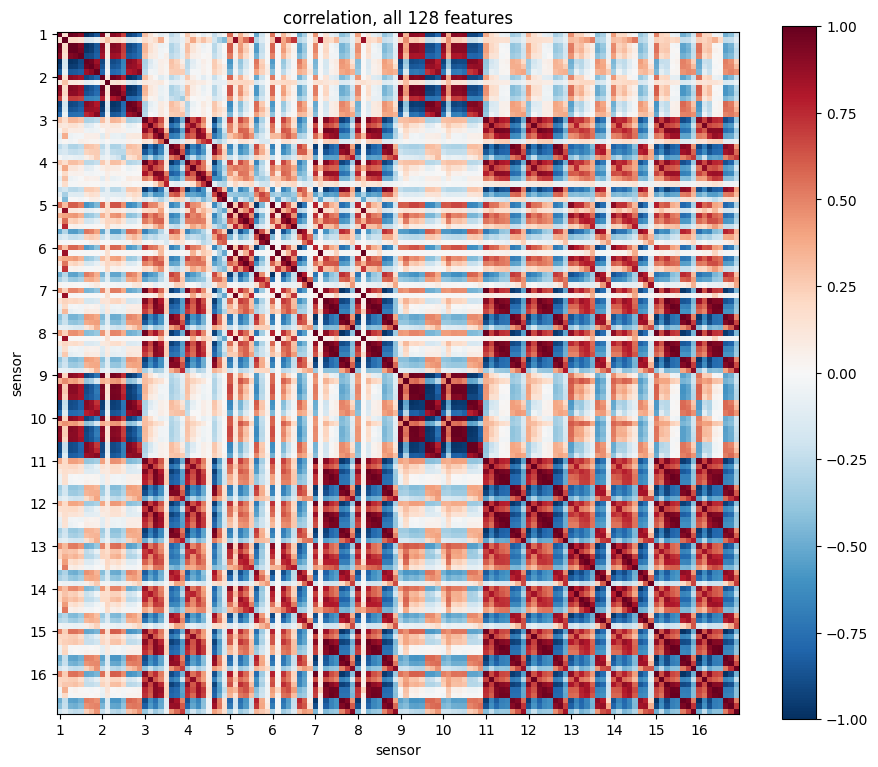

In [11]:
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(train[FEATS].corr(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(0, 128, 8), range(1, 17))
ax.set_yticks(range(0, 128, 8), range(1, 17))
ax.set_xlabel("sensor"); ax.set_ylabel("sensor")
ax.set_title("correlation, all 128 features")
fig.colorbar(im); plt.show()


The heatmap shows 16 clear blocks of 8 along the diagonal: the features are grouped as 8 measurements per sensor, in order. Between blocks there is still heavy correlation, so the sensors are largely measuring the same events.

That rules out a plain multiple logistic regression, which assumes non-collinear predictors. We could pair feature selection with it, but with 6 classes it would need a multinomial rather than the binomial form we would prefer, and with 128 candidate predictors the selection itself would overfit. We tried it, along with tree models; neither worked well, and §8.7 shows why with numbers. We went with LDA plus shrinkage instead, which handles the collinearity in the covariance estimate rather than by throwing columns away.

In [12]:
vif = np.diag(np.linalg.pinv(np.corrcoef(Z, rowvar=False)))
print(f"max VIF {vif.max():.1f}, median {np.median(vif):.1f}, "
      f"{(vif>10).sum()}/{p} above 10")
print(f"   condition number {np.linalg.cond(Z):.1f}")

max VIF 10085.1, median 618.3, 128/128 above 10
   condition number 1507.7


Comprehensively collinear: every one of the 128 features has a VIF above 10, the median is 618, and the worst is 10,085. A multiple logistic regression on these features is not salvageable by dropping a few columns - the redundancy is structural, because the sensors are measuring overlapping things. Either we select features aggressively, or we regularise the covariance estimate. §4 takes the second route.

## 4. Ledoit-Wolf shrinkage

We want to get rid of the collinearity, and the method we chose was Ledoit-Wolf shrinkage. We
looked at hand feature selection, but with 128 features and 48 hours it was not worth the
small improvement, and with 128 predictors it would be easy to overfit through the selection
itself. Ledoit-Wolf's primary purpose is not decollinearisation, but it regularises the
covariance estimate that LDA depends on, which is where the collinearity actually bites.

The feature builder below is used unchanged by every model in this notebook.

### helper functions

In [13]:
FEATS = [f"feat_{i}" for i in range(1, 129)]

def make_features(df):
    """145 cols: log steady-state, log EMA, response per unit gas, log concentration."""
    A    = df[FEATS].to_numpy()
    conc = df.concentration.to_numpy()[:, None]
    slog = lambda x: np.sign(x) * np.log1p(np.abs(x))
    steady = A[:, ::8]                                  # 16 steady-state cols
    ema    = np.delete(A, np.arange(0, 128, 8), axis=1)  # 112 EMA cols
    return np.column_stack([slog(steady), slog(ema), slog(steady / conc), np.log1p(conc)])

### fitting

In [14]:
X_lw = make_features(train)
y_lw = train.gas_class.to_numpy()
b_lw = train.batch.to_numpy()
tr, va = b_lw < 9, b_lw == 9

sc9 = StandardScaler().fit(X_lw[tr])
lda9 = LinearDiscriminantAnalysis(solver="eigen", covariance_estimator=LedoitWolf())
lda9.fit(sc9.transform(X_lw[tr]), y_lw[tr])

print("batch-9 macro-F1:",
      f1_score(y_lw[va], lda9.predict(sc9.transform(X_lw[va])), average="macro"))

batch-9 macro-F1: 0.9644235426306883


### submission making

In [15]:
X_train = make_features(train)
X_test  = make_features(test)
y_train = train.gas_class.to_numpy()

scaler = StandardScaler().fit(X_train)
lda = LinearDiscriminantAnalysis(solver="eigen", covariance_estimator=LedoitWolf())
lda.fit(scaler.transform(X_train), y_train)

pred = lda.predict(scaler.transform(X_test))

sub = pd.DataFrame({"measurement_id": test.measurement_id, "gas_class": pred})
sub.to_csv("lda_lw.csv", index=False)
print(sub.gas_class.value_counts().sort_index())

gas_class
1    835
2    564
3    578
4    516
5    539
6    568
Name: count, dtype: int64


scored 0.87 pretty good. We were pretty sure that shrinking to get rid of collinearity was the go. however we were thinking cos the entire time we assumed the data was a linear relationship, that what if it wasn't actually linear. therefore enter QUADRATIC da

## 5. Would a non-linear model be better?

We had assumed a linear relationship throughout. Worth testing: if the true boundaries are
curved, QDA - which fits a separate covariance per class instead of one shared one - should
beat LDA.

In [16]:
tr, va = (train.batch < 9).values, (train.batch == 9).values
sc = StandardScaler().fit(X_train[tr])
Xs, Xv = sc.transform(X_train[tr]), sc.transform(X_train[va])

for r in [0.0, 0.01, 0.1, 0.3, 0.5, 0.8]:
    qda = QuadraticDiscriminantAnalysis(reg_param=r).fit(Xs, y_train[tr])
    print(f"reg_param={r:<5g} batch-9 macro-F1 = "
          f"{f1_score(y_train[va], qda.predict(Xv), average='macro'):.4f}")


reg_param=0     batch-9 macro-F1 = 0.7961

C:\Users\Sean Wang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Sean Wang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Sean Wang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might he


reg_param=0.01  batch-9 macro-F1 = 0.7165


reg_param=0.1   batch-9 macro-F1 = 0.9439
reg_param=0.3   batch-9 macro-F1 = 0.9736


reg_param=0.5   batch-9 macro-F1 = 0.9710
reg_param=0.8   batch-9 macro-F1 = 0.9425


In [17]:
scaler = StandardScaler().fit(X_train)
qda = QuadraticDiscriminantAnalysis(reg_param=0.3)
qda.fit(scaler.transform(X_train), y_train)

pred = qda.predict(scaler.transform(X_test))

sub = pd.DataFrame({"measurement_id": test.measurement_id, "gas_class": pred})
sub.to_csv("qda.csv", index=False)
print(sub.gas_class.value_counts().sort_index())

gas_class
1     531
2     648
3     534
4    1068
5     491
6     328
Name: count, dtype: int64


Abort. Scored 0.67 on the leaderboard, well below the 0.87 of the linear model, so we went
back to LDA for the remaining work.

At the time we read this as "the relationship is linear". That reading is too quick: QDA
actually scored **better** than LDA on our batch-9 holdout (0.9736 vs 0.9644) and then
collapsed on the leaderboard. A model cannot be both better and much worse for the reason
"the data is linear". We diagnose what actually happened in §8.5 - it is a more useful
finding than the one we recorded here.

## 6. Using batch as information

we noticed that the measurement between different batches were a little off. i.e. batch 1 features for class 1 gas is different from batch 2 features for class 1 gas.

### building averaged gas tables

In [18]:
FEATS = [f"feat_{i}" for i in range(1, 129)]
slog = lambda x: np.sign(x) * np.log1p(np.abs(x))

Xz = slog(train[FEATS].to_numpy())
Xz = (Xz - Xz.mean(0)) / Xz.std(0)      # standardise so all features are comparable
y_, b_ = train.gas_class.to_numpy(), train.batch.to_numpy()

M = np.full((9, 6, 128), np.nan)        # [batch, gas, feature]
for i, bb in enumerate(range(1, 10)):
    for k in range(6):
        m = (b_ == bb) & (y_ == k + 1)
        if m.sum() >= 5:
            M[i, k] = Xz[m].mean(0)

print(M.shape)   # (9, 6, 128)


(9, 6, 128)


### feature 1 for each gas class mean per batch

,gas1,gas2,gas3,gas4,gas5,gas6
b1,0.82,-0.39,-0.30,1.32,1.60,1.05
b2,0.44,-0.39,-0.15,0.81,1.35,1.00
b3,0.76,-0.60,-0.23,0.64,1.04,NaN
b4,0.17,-0.82,-0.21,0.18,1.29,NaN
b5,0.92,-0.75,0.15,0.76,1.20,NaN
b6,0.53,-0.62,-0.17,0.62,0.78,0.57
b7,0.13,-0.57,-1.77,-0.40,0.16,-0.69
b8,-0.75,-1.95,-2.98,-2.15,-1.77,-0.98
b9,0.03,-0.74,-0.39,0.09,0.40,-0.15


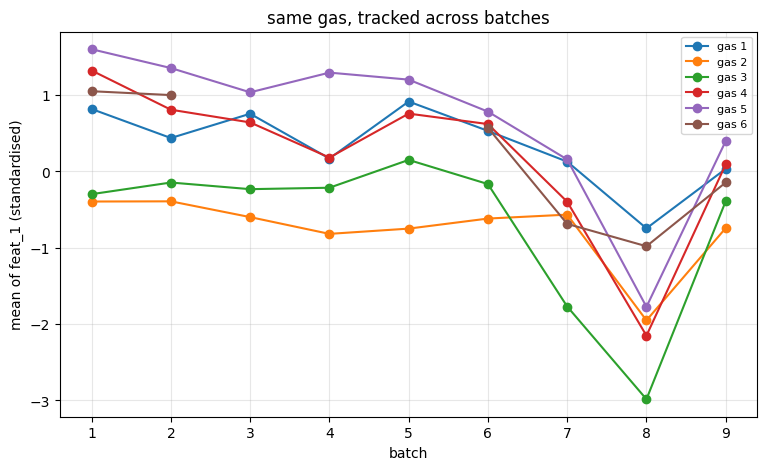

In [19]:
tbl = pd.DataFrame(M[:, :, 0],
                   index=[f"b{i}" for i in range(1, 10)],
                   columns=[f"gas{k}" for k in range(1, 7)])
display(tbl.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
for k in range(6):
    ax.plot(range(1, 10), M[:, k, 0], marker="o", label=f"gas {k+1}")
ax.set_xlabel("batch"); ax.set_ylabel("mean of feat_1 (standardised)")
ax.set_title("same gas, tracked across batches")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.show()

The same gas gives measurably different readings depending on which batch it was measured in - the lines for a single gas move up and down across batches rather than staying flat. So batch identity carries information that is currently polluting the features, and the model should be told about it. §1.3 quantified the size of these offsets; the next cell tries to remove them.

### feature engineering each batch
note: we later also realised that in the given data overview, that sensor drift is confirmed to be a property of the data, further strengthening our claim here

ok so the idea is that we assume that each feature has 2 components: One from itself reacting to the gas (this is what is wot we hypothesise carries the information) (we call this $\alpha_{\text{self}}$) PLUS the component because of the batch (does NOT carry any information so we want to remove this). We can represent this really crudely just by using the feature mean for that batch (call this component $\mu_{\text{batch}}$). Therefore for each feature:

$\alpha_{\text{self}} = \alpha_{\text{total}}-\mu_{\text{batch}}$ 

In [20]:
# make_features is defined in §4 and reused unchanged; balanced_mean is the new helper.
def balanced_mean(X, y, m):
    """Mean of the per-class means. Unbiased when a batch's class mix is uneven (§1.1),
    which a plain mean is not."""
    ks = [k for k in np.unique(y[m]) if (m & (y == k)).sum() >= 5]
    return np.mean([X[m & (y == k)].mean(0) for k in ks], axis=0)

X_train = make_features(train)
X_test  = make_features(test)
y_train = train.gas_class.to_numpy()
b_train = train.batch.to_numpy()

X_tr = X_train.copy()
for bb in np.unique(b_train):
    m = b_train == bb
    X_tr[m] -= balanced_mean(X_train, y_train, m)     # labels available -> class-balanced

X_te = X_test - X_test.mean(0)                        # no labels -> plain mean (tested in §8.3)


and just a quick check to see if the issue of the features varying so much has been fixed now...

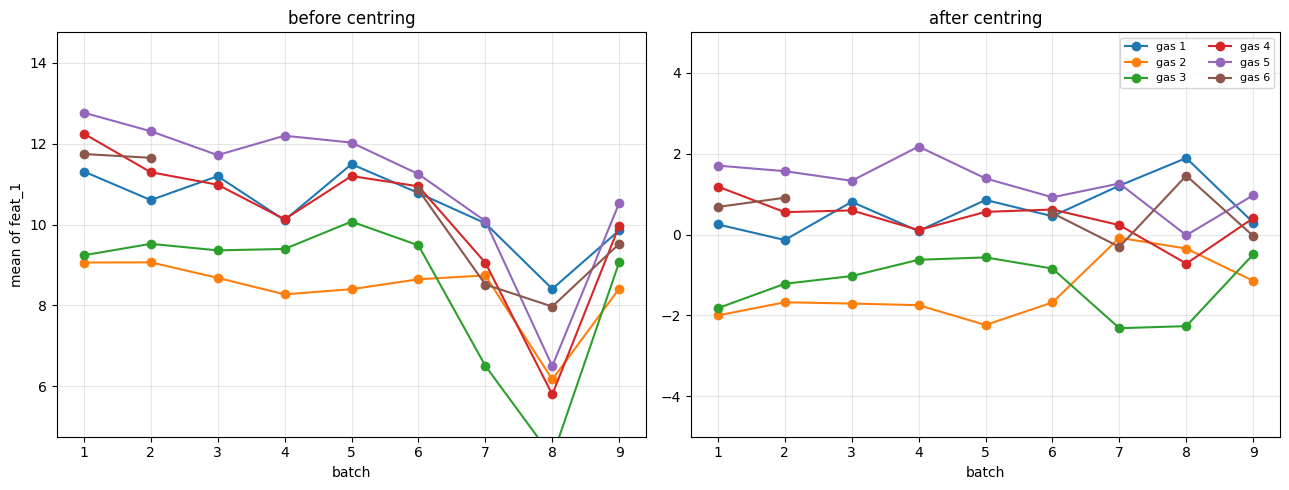

In [21]:
### did the centring flatten the batch effect?
def gas_means(V):
    M = np.full((9, 6), np.nan)
    for i in range(9):
        for k in range(6):
            m = (b_train == i + 1) & (y_train == k + 1)
            if m.sum() >= 5: M[i, k] = V[m].mean()
    return M

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, M, t in zip(axes, [gas_means(X_train[:, 0]), gas_means(X_tr[:, 0])],
                    ["before centring", "after centring"]):
    for k in range(6):
        ax.plot(range(1, 10), M[:, k], marker="o", label=f"gas {k+1}")
    ax.set_ylim(np.nanmean(M) - 5, np.nanmean(M) + 5)   # same window on both, so the wiggle compares
    ax.set_xlabel("batch"); ax.set_title(t); ax.grid(alpha=.3)
axes[0].set_ylabel("mean of feat_1")
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


It works. Before centring, the per-gas lines wander across batches - the same gas reads differently in each one. After centring they flatten out and separate cleanly by gas, which is what we want: the batch offset is gone and what remains distinguishes the gases rather than the measurement session.

Both panels use the same y-window, so the reduction in wiggle is a fair comparison and not an artefact of rescaling.

### fitting

In [22]:
va = b_train == 9

X_fit  = X_tr[~va]                                 # batches 1-8, already centred by the cell above
X_hold = X_train[va] - X_train[va].mean(0)         # batch 9, plain mean -- no labels used

s = StandardScaler().fit(X_fit)
lda9 = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
lda9.fit(s.transform(X_fit), y_train[~va])

p9 = lda9.predict(s.transform(X_hold))
print(f"batch-9 macro-F1: {f1_score(y_train[va], p9, average='macro'):.4f}")
print(classification_report(y_train[va], p9, digits=4))

batch-9 macro-F1: 0.9727
              precision    recall  f1-score   support

           1     0.9385    1.0000    0.9683        61
           2     1.0000    1.0000    1.0000        55
           3     1.0000    1.0000    1.0000       100
           4     0.9000    0.9600    0.9290        75
           5     1.0000    0.8846    0.9388        78
           6     1.0000    1.0000    1.0000       101

    accuracy                         0.9745       470
   macro avg     0.9731    0.9741    0.9727       470
weighted avg     0.9761    0.9745    0.9744       470



0.9727 against 0.9644 for the uncentred model on the same held-out batch, and the per-class report is clean - only gas 4 and gas 5 are confused at all. Batches do carry information, and removing it helps.

One caution we should have taken more seriously at the time: this is a single held-out batch of 470 rows, and an 0.008 difference on one batch is thin evidence. §8.2 re-runs the comparison across seven batches and the picture is more complicated.

### submission

In [23]:
scaler = StandardScaler().fit(X_tr)
lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
lda.fit(scaler.transform(X_tr), y_train)

pred = lda.predict(scaler.transform(X_te))

sub = pd.DataFrame({"measurement_id": test.measurement_id, "gas_class": pred})
sub.to_csv("lda_centered.csv", index=False)
print(sub.gas_class.value_counts().sort_index())

gas_class
1    699
2    565
3    593
4    609
5    545
6    589
Name: count, dtype: int64


This scored 0.901, up from 0.870 - our biggest single improvement, and it confirms that the
batch effect is real and removable.

Two things to be careful about, both taken up in §8: the change bundled a solver switch in
with the centring (§8.2 separates them), and the test batch is centred with a plain mean
while training batches use a class-balanced one (§8.3 tests whether that asymmetry is safe).

## 7. Self-training on the unlabelled test batch

Batch 10's *features* are available even though its labels are not, and §1.3 says its offset
is its own. A model fitted only on batches 1-9 never sees that geometry.

Self-training uses it: predict the test batch, keep the most confident predictions per class,
add them back as pseudo-labels, refit, and repeat with a widening fraction (0.40 to 0.98 over
8 rounds). No test labels are used at any point - only the unlabelled features, which are
supplied in `test.csv`.

This is the model we submitted. It is validated in §8.8.

In [24]:
sh, rounds, w = "auto", 8, 3

X_train = make_features(train)
X_test  = make_features(test)
y_train = train.gas_class.to_numpy()
b_train = train.batch.to_numpy()

X_tr = X_train.copy()
for bb in np.unique(b_train):
    m = b_train == bb
    X_tr[m] -= balanced_mean(X_train, y_train, m)
X_te = X_test - X_test.mean(0)

scaler = StandardScaler().fit(X_tr)
Zs, Zt = scaler.transform(X_tr), scaler.transform(X_te)

MK = lambda: LinearDiscriminantAnalysis(solver="lsqr", shrinkage=sh)

model = MK().fit(Zs, y_train)
for r in range(rounds):
    frac = 0.4 + (0.98 - 0.4) * r / max(rounds - 1, 1)
    P = model.predict_proba(Zt)
    s = np.sort(P, axis=1)
    conf, pred = s[:, -1] - s[:, -2], model.classes_[P.argmax(1)]

    keep = np.zeros(len(Zt), bool)
    for k in np.unique(pred):
        i = np.where(pred == k)[0]
        keep[i[np.argsort(conf[i])[::-1][:max(1, int(round(frac * len(i))))]]] = True

    model = MK().fit(np.vstack([Zs, np.repeat(Zt[keep], w, axis=0)]),
                     np.concatenate([y_train, np.repeat(pred[keep], w)]))

if len(np.unique(pred[keep])) == 6:
    model = MK().fit(Zt[keep], pred[keep])

final = model.predict(Zt)
sub = pd.DataFrame({"measurement_id": test.measurement_id, "gas_class": final})
sub.to_csv("lda_tuned.csv", index=False)
print(sub.gas_class.value_counts().sort_index())


gas_class
1    610
2    603
3    597
4    676
5    545
6    569
Name: count, dtype: int64


# 8. Validation, ablations and diagnostics

Sections 1-7 are the path we took. This section is the evidence for it: a validation protocol
that reflects the actual task, and the experiments that check each decision we made along the
way - including the two we got wrong on the first pass.

### 8.1 Protocol

The task is *extrapolation to an unseen batch*, so validation has to be too. We use an
**expanding window**: to score held-out batch `f`, train on every batch before it. This
mirrors train 1-9 / predict 10 at several points, and gives 7 estimates instead of the single
batch-9 number we were using in §4-§6.

Two details make the estimate honest:

- the held-out batch is centred with its own **plain** mean, never a class-balanced one,
  because at submission time we have no test labels to compute one from;
- macro-F1 is taken over the classes actually present in the held-out batch, since batches 3,
  4 and 5 have no class 6 (§1.1).

Batches 1-2 are the minimum viable training set, so folds run over batches 3-9. Folds 7-9
carry the largest training sets and are the closest analogue to the real task; we report the
full spread and that subset separately.

In [25]:
V_X = make_features(train)          # the same 145 features every submission uses
V_y = train.gas_class.to_numpy()
V_b = train.batch.to_numpy()
V_FOLDS = range(3, 10)
V_LATE = [7, 8, 9]                  # large training sets: closest to the real task

def v_centre(X_raw, y_sub, b_sub):
    '''Per-batch centring of a training block, using the class-balanced mean (§1.1).'''
    out = X_raw.copy()
    for bb in np.unique(b_sub):
        m = b_sub == bb
        out[m] -= balanced_mean(X_raw, y_sub, m)
    return out

def v_selftrain(mk, Zs, ys, Zt, rounds=8, w=3):
    '''Exactly the loop used for the submission in §7.'''
    model = mk().fit(Zs, ys)
    for r in range(rounds):
        frac = 0.4 + (0.98 - 0.4) * r / max(rounds - 1, 1)
        P = model.predict_proba(Zt)
        s = np.sort(P, axis=1)
        conf, pred = s[:, -1] - s[:, -2], model.classes_[P.argmax(1)]
        keep = np.zeros(len(Zt), bool)
        for k in np.unique(pred):
            i = np.where(pred == k)[0]
            keep[i[np.argsort(conf[i])[::-1][:max(1, int(round(frac * len(i))))]]] = True
        model = mk().fit(np.vstack([Zs, np.repeat(Zt[keep], w, axis=0)]),
                         np.concatenate([ys, np.repeat(pred[keep], w)]))
    if len(np.unique(pred[keep])) == 6:
        model = mk().fit(Zt[keep], pred[keep])
    return model

def v_score(mk, folds=V_FOLDS, centred=True, expanding=True, cols=None,
            selftrain=False, X=None, **st_kw):
    '''macro-F1 per held-out batch. cols=None uses all 145 features.'''
    X = V_X if X is None else X
    if cols is not None:
        X = X[:, cols]
    out = {}
    for f in folds:
        tr_m = (V_b < f) if expanding else (V_b != f)
        te_m = V_b == f
        Xtr, Xte = X[tr_m], X[te_m]
        if centred:
            Xtr = v_centre(Xtr, V_y[tr_m], V_b[tr_m])
            Xte = Xte - Xte.mean(0)                      # no labels used on the held-out batch
        s = StandardScaler().fit(Xtr)
        Zs, Zt = s.transform(Xtr), s.transform(Xte)
        mdl = (v_selftrain(mk, Zs, V_y[tr_m], Zt, **st_kw) if selftrain
               else mk().fit(Zs, V_y[tr_m]))
        out[f] = f1_score(V_y[te_m], mdl.predict(Zt), average="macro",
                          labels=np.unique(V_y[te_m]))
    return out

def v_row(name, d):
    v = np.array(list(d.values()))
    late = np.mean([d[f] for f in V_LATE if f in d])
    print(f"  {name:26s} all folds {v.mean():.4f} +/- {v.std():.4f}   "
          f"folds 7-9 {late:.4f}   per-fold {[round(float(x), 3) for x in v]}")

MK_LW   = lambda: LinearDiscriminantAnalysis(solver="eigen", covariance_estimator=LedoitWolf())
MK_LSQR = lambda: LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")

# sanity check: the harness must reproduce the two numbers reported in §4 and §6
_chk_lw = v_score(MK_LW, folds=[9], centred=False)[9]
_chk_ct = v_score(MK_LSQR, folds=[9], centred=True)[9]
print(f"harness check -- batch-9, uncentred Ledoit-Wolf : {_chk_lw:.4f}   (§4 reported 0.9644)")
print(f"harness check -- batch-9, centred lsqr         : {_chk_ct:.4f}   (§6 reported 0.9727)")

harness check -- batch-9, uncentred Ledoit-Wolf : 0.9644   (§4 reported 0.9644)


harness check -- batch-9, centred lsqr         : 0.9727   (§6 reported 0.9727)


### 8.2 Was it the centring, or the solver?

Between §4 and §6 we changed two things at once: we added per-batch centring, and we
switched from `eigen` + explicit Ledoit-Wolf to `lsqr` + `shrinkage="auto"`. The leaderboard
went 0.870 to 0.901, but that comparison cannot say which change earned it. A 2x2 can.

In [26]:
print("solver x centring, expanding window:")
for nm, mk in [("LDA eigen+LedoitWolf", MK_LW), ("LDA lsqr+auto", MK_LSQR)]:
    for cen in [False, True]:
        v_row(f"{nm} [{'centred' if cen else 'raw'}]", v_score(mk, centred=cen))

solver x centring, expanding window:


  LDA eigen+LedoitWolf [raw] all folds 0.9128 +/- 0.0585   folds 7-9 0.9317   per-fold [0.941, 0.805, 0.99, 0.859, 0.926, 0.905, 0.964]


  LDA eigen+LedoitWolf [centred] all folds 0.8728 +/- 0.0992   folds 7-9 0.9286   per-fold [0.85, 0.805, 0.986, 0.683, 0.943, 0.87, 0.973]


  LDA lsqr+auto [raw]        all folds 0.9123 +/- 0.0579   folds 7-9 0.9344   per-fold [0.933, 0.799, 0.982, 0.869, 0.931, 0.905, 0.967]


  LDA lsqr+auto [centred]    all folds 0.8745 +/- 0.1022   folds 7-9 0.9346   per-fold [0.858, 0.791, 0.99, 0.68, 0.945, 0.886, 0.973]


**The solver is a wash.** `eigen` + Ledoit-Wolf and `lsqr` + `auto` land within 0.002 of each
other in both the raw and centred conditions - unsurprising, since `shrinkage="auto"` *is*
the Ledoit-Wolf estimator. Our §6 improvement was not the solver.

**Centring is not universally better either**, which is the more interesting result. Averaged
over all 7 folds the centred model is *worse* (0.875 vs 0.912). But look at the per-fold
numbers rather than the mean: centring helps on folds 7 and 9 and badly hurts on folds 3 and
6. Something distinguishes those folds, and it is not noise. §8.3 identifies it.

### 8.3 When does the centring correction actually work?

The correction has an assumption baked in that we did not state when we built it. Training
batches are centred with a class-balanced mean, because we hold their labels. The test batch
has no labels, so it is centred with a **plain** mean - and a plain mean only estimates the
same quantity if the batch's class mix is roughly even. §1.1 showed the batches vary
enormously on exactly that.

So: does the centring gain track how class-balanced the held-out batch is?

In [27]:
def evenness(counts):
    '''Normalised entropy of a class distribution: 1.0 = perfectly even, 0 = one class.'''
    p = counts[counts > 0] / counts.sum()
    return float(-(p * np.log(p)).sum() / np.log(6))

raw_d, cen_d = v_score(MK_LSQR, centred=False), v_score(MK_LSQR, centred=True)
rows = []
for f in V_FOLDS:
    cnt = np.array([(V_y[V_b == f] == k).sum() for k in range(1, 7)])
    rows.append({"held-out batch": f, "n": int((V_b == f).sum()), "evenness": round(evenness(cnt), 3),
                 "raw": round(raw_d[f], 3), "centred": round(cen_d[f], 3),
                 "gain": round(cen_d[f] - raw_d[f], 3)})
tab = pd.DataFrame(rows).set_index("held-out batch")
display(tab)

ev, gain = tab.evenness.to_numpy(), tab.gain.to_numpy()
print(f"correlation(evenness, centring gain) = {np.corrcoef(ev, gain)[0, 1]:.3f}")
print(f"  balanced held-out batches (evenness > 0.95): mean gain {gain[ev > 0.95].mean():+.4f}")
print(f"  skewed   held-out batches (evenness <= 0.95): mean gain {gain[ev <= 0.95].mean():+.4f}")

sub_final = pd.read_csv("lda_centered.csv").gas_class.to_numpy()
cnt10 = np.array([(sub_final == k).sum() for k in range(1, 7)])
print(f"\nbatch 10 predicted composition {cnt10.tolist()} -> evenness {evenness(cnt10):.3f}")

,n,evenness,raw,centred,gain
held-out batch,,,,,
3,1586,0.872,0.933,0.858,-0.076
4,161,0.792,0.799,0.791,-0.008
5,197,0.858,0.982,0.990,0.008
6,2300,0.869,0.869,0.680,-0.188
7,3613,0.988,0.931,0.945,0.014
8,294,0.840,0.905,0.886,-0.019
9,470,0.986,0.967,0.973,0.006


correlation(evenness, centring gain) = 0.242
  balanced held-out batches (evenness > 0.95): mean gain +0.0100
  skewed   held-out batches (evenness <= 0.95): mean gain -0.0566

batch 10 predicted composition [699, 565, 593, 609, 545, 589] -> evenness 0.998


There it is. On held-out batches whose class mix is close to even the correction gains
+0.010 on average; on skewed batches it loses **-0.057**. Fold 6 is the extreme case - batch 6
has 29 class-4 measurements against 606 class-5, and centring it on its own plain mean costs
0.19 macro-F1.

The mechanism is straightforward. Subtracting a plain mean from a batch dominated by one class
subtracts part of *that class's signal*, not just the batch offset. The class-balanced mean we
use on training batches is immune to this; the plain mean we are forced into at test time is
not.

**And batch 10 has an evenness of 0.998** - as even as a batch can be. The assumption is
satisfied for the batch we actually had to predict, which is why the correction gained
+0.031 on the leaderboard rather than costing us. That is a real limitation of the method,
not a general result: on a skewed test batch this correction would have hurt us, and we would
not have been able to tell from the test features alone.

An honest caveat on the number above: batch 10's composition is *predicted*, not known, so
the evenness figure inherits our model's errors. It would take a very skewed truth to look
this even, but we cannot verify it.

### 8.4 A second look: leave-one-batch-out

The expanding window is faithful to the task but spends its early folds on tiny training sets
(fold 3 trains on 1,689 rows). Leave-one-batch-out trains on every *other* batch, so each fold
gets a realistic amount of data. It is a weaker analogue of the real task - the model sees
batches from both sides of the held-out one - but a better estimate of the ceiling.

In [28]:
lobo_raw = v_score(MK_LSQR, folds=range(1, 10), centred=False, expanding=False)
lobo_cen = v_score(MK_LSQR, folds=range(1, 10), centred=True,  expanding=False)
lobo = pd.DataFrame({"raw": lobo_raw, "centred": lobo_cen}).round(3)
lobo["gain"] = (lobo.centred - lobo.raw).round(3)
lobo.index.name = "held-out batch"
display(lobo)
print(f"mean raw {lobo.raw.mean():.3f} | mean centred {lobo.centred.mean():.3f} "
      f"| mean gain {lobo.gain.mean():+.3f}")

,raw,centred,gain
held-out batch,,,
1,0.680,0.731,0.051
2,0.892,0.882,-0.010
3,0.990,0.988,-0.002
4,0.954,0.913,-0.041
5,0.993,0.993,0.000
6,0.972,0.975,0.003
7,0.931,0.983,0.052
8,0.931,0.929,-0.002
9,0.967,0.973,0.006


mean raw 0.923 | mean centred 0.930 | mean gain +0.006


With realistic training-set sizes the centring is mildly positive on average (+0.006) and
gains most where the held-out batch is large and even - batch 7, +0.052. Consistent with
§8.3, and it puts the method in its proper place: a small, conditional improvement, not the
transformation the single batch-9 comparison in §6 suggested.

The honest summary of §8.2-§8.4 is that our headline +0.031 on the leaderboard is larger
than our cross-validated estimate of the effect. Some of it is a genuinely favourable test
batch, and some of it is that a single leaderboard comparison is one noisy draw.

### 8.5 Why QDA won on batch 9 and lost by 0.20 on batch 10

The QDA result in §5 is the most informative thing that happened in this notebook, and our
first explanation of it was wrong. QDA scored 0.9736 on batch 9 - *better* than LDA's 0.9644 -
then scored 0.67 on the leaderboard against LDA's 0.87. "The data is linear" cannot explain a
model that wins on one held-out batch and loses badly on another.

The expanding window scores it on seven batches instead of one, which makes the pattern
visible.

In [29]:
# QDA raises LinAlgWarning on every fit here. The rank deficiency is exactly what this
# comparison is about (see §5), so we silence the repeats rather than hide the issue.
import warnings
from scipy.linalg import LinAlgWarning

print("stability across held-out batches:")
for nm, mk in [("QDA reg=0.3", lambda: QuadraticDiscriminantAnalysis(reg_param=0.3)),
               ("QDA reg=0.5", lambda: QuadraticDiscriminantAnalysis(reg_param=0.5)),
               ("LDA lsqr+auto", MK_LSQR)]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", LinAlgWarning)
        d = v_score(mk, centred=True)
    v = np.array(list(d.values()))
    print(f"  {nm:16s} mean {v.mean():.4f}   sd {v.std():.4f}   worst fold {v.min():.4f}   "
          f"per-fold {[round(float(x), 3) for x in v]}")

stability across held-out batches:


  QDA reg=0.3      mean 0.8272   sd 0.1378   worst fold 0.5699   per-fold [0.931, 0.861, 0.988, 0.57, 0.8, 0.702, 0.939]


  QDA reg=0.5      mean 0.7861   sd 0.1491   worst fold 0.5693   per-fold [0.957, 0.854, 0.988, 0.569, 0.792, 0.609, 0.733]


  LDA lsqr+auto    mean 0.8745   sd 0.1022   worst fold 0.6803   per-fold [0.858, 0.791, 0.99, 0.68, 0.945, 0.886, 0.973]


The difference is variance, not level. QDA's spread across batches is 0.138 against LDA's
0.102, and its worst fold is 0.570 against LDA's 0.680. QDA is a *higher-variance estimator
across batches*, so picking it on the strength of one favourable batch was always a coin flip.

The mechanism is specific to this dataset. LDA estimates one shared covariance matrix pooled
over every class and batch; QDA estimates six, one per class, each from a fraction of the
data. Under drift each class's covariance is being estimated from measurements taken under
different sensor conditions, and those six estimates degrade independently. Whether they
happen to suit an unseen batch is close to luck - and batch 10 was unlucky.

The correct lesson, which we did not draw at the time, is **not** "the relationship is
linear". It is that model selection on a single held-out batch is unreliable in exactly
proportion to how much a model's variance depends on batch composition. That argument
generalises past QDA, and it is the reason §8.1 exists.

### 8.6 Do the engineered features earn their place?

`make_features` builds four blocks: 16 log steady-state columns, 112 log EMA columns, 16
response-per-unit-gas columns (steady / concentration), and log concentration. We never
checked which of them matter.

In [30]:
n_st, n_em = 16, 112
IDX = {"steady": np.arange(0, 16), "ema": np.arange(16, 128),
       "sens": np.arange(128, 144), "conc": np.array([144])}
def cols(*names): return np.concatenate([IDX[n] for n in names])

for nm, cs in [("full (145)",            cols("steady", "ema", "sens", "conc")),
               ("no sensitivity (129)",  cols("steady", "ema", "conc")),
               ("no log-conc (144)",     cols("steady", "ema", "sens")),
               ("no EMA (33)",           cols("steady", "sens", "conc")),
               ("steady only (16)",      cols("steady")),
               ("EMA only (112)",        cols("ema")),
               ("sensitivity only (16)", cols("sens"))]:
    v_row(nm, v_score(MK_LSQR, cols=cs))

  full (145)                 all folds 0.8745 +/- 0.1022   folds 7-9 0.9346   per-fold [0.858, 0.791, 0.99, 0.68, 0.945, 0.886, 0.973]


  no sensitivity (129)       all folds 0.8719 +/- 0.1050   folds 7-9 0.9360   per-fold [0.852, 0.78, 0.99, 0.674, 0.943, 0.894, 0.971]


  no log-conc (144)          all folds 0.8753 +/- 0.1032   folds 7-9 0.9351   per-fold [0.869, 0.785, 0.99, 0.678, 0.946, 0.887, 0.972]
  no EMA (33)                all folds 0.8067 +/- 0.1274   folds 7-9 0.8698   per-fold [0.771, 0.621, 0.986, 0.66, 0.798, 0.858, 0.953]
  steady only (16)           all folds 0.6710 +/- 0.1286   folds 7-9 0.7735   per-fold [0.501, 0.603, 0.697, 0.576, 0.632, 0.771, 0.918]


  EMA only (112)             all folds 0.8755 +/- 0.1062   folds 7-9 0.9322   per-fold [0.886, 0.796, 0.99, 0.661, 0.944, 0.884, 0.969]
  sensitivity only (16)      all folds 0.8049 +/- 0.1212   folds 7-9 0.8639   per-fold [0.729, 0.656, 0.986, 0.672, 0.787, 0.851, 0.953]


Deflating, and worth reporting as such. **The EMA block is doing essentially all the work**:
EMA alone scores 0.8755, indistinguishable from the full 145-feature set at 0.8745. Dropping
the sensitivity block costs 0.003; dropping log-concentration costs nothing measurable.

So the response-per-unit-gas idea, which is the one piece of genuine chemistry reasoning in
our feature set, does not measurably help once 112 EMA columns are present. We would keep it
- it costs nothing and is defensible on domain grounds - but we should not claim it as a
contributor.

The blocks that *do* matter are the ones we did least to: steady-state alone is 0.671, so the
transient EMA response carries far more class information than the steady-state level. If we
had another 48 hours, exploring the EMA channels further is where we would spend it, not on
more feature blocks of our own design.

One loose end from §4: we normalise the steady-state columns by concentration but not the EMA
columns, which is an asymmetry we never justified. Testing it directly.

In [31]:
_em_raw = np.delete(train[FEATS_ALL].to_numpy(), np.arange(0, 128, 8), axis=1)
_ratio = _em_raw / train.concentration.to_numpy()[:, None]
V_X_plus = np.column_stack([V_X, np.sign(_ratio) * np.log1p(np.abs(_ratio))])

v_row("full (145)", v_score(MK_LSQR))
v_row("full + EMA/conc (257)", v_score(MK_LSQR, X=V_X_plus))

  full (145)                 all folds 0.8745 +/- 0.1022   folds 7-9 0.9346   per-fold [0.858, 0.791, 0.99, 0.68, 0.945, 0.886, 0.973]


  full + EMA/conc (257)      all folds 0.8606 +/- 0.1193   folds 7-9 0.9035   per-fold [0.941, 0.756, 0.986, 0.631, 0.911, 0.837, 0.962]


0.861 against 0.875 - adding the EMA-per-concentration block makes things slightly worse.
The asymmetry was accidental, but it happens to be the right call: with 112 EMA columns
already present, the normalised copies add collinearity and no new information. Recorded here
because a reader would otherwise reasonably ask why we only normalised half the features.

### 8.7 The models we said we tried

§3 asserts that logistic regression and tree models "didn't really work very well" without
showing anything. That claim should not be taken on trust, so here it is under the same
protocol as everything else.

In [32]:
for nm, mk in [("multinomial logistic", lambda: LogisticRegression(max_iter=2000)),
               ("random forest (400)",  lambda: RandomForestClassifier(n_estimators=400,
                                                                       random_state=0, n_jobs=-1)),
               ("hist gradient boosting", lambda: HistGradientBoostingClassifier(random_state=0)),
               ("LDA lsqr+auto",        MK_LSQR)]:
    v_row(nm, v_score(mk, centred=True))

  multinomial logistic       all folds 0.8124 +/- 0.0968   folds 7-9 0.8028   per-fold [0.852, 0.801, 0.983, 0.643, 0.858, 0.802, 0.749]


  random forest (400)        all folds 0.7576 +/- 0.1335   folds 7-9 0.6842   per-fold [0.922, 0.763, 0.956, 0.609, 0.733, 0.569, 0.751]


  hist gradient boosting     all folds 0.7011 +/- 0.1389   folds 7-9 0.6791   per-fold [0.696, 0.674, 0.975, 0.526, 0.753, 0.544, 0.74]


  LDA lsqr+auto              all folds 0.8745 +/- 0.1022   folds 7-9 0.9346   per-fold [0.858, 0.791, 0.99, 0.68, 0.945, 0.886, 0.973]


The claim holds, and the ordering is informative. Logistic regression reaches 0.812 - it
handles the collinearity worse than shrinkage LDA does, as §3's VIFs predicted. Both tree
models do clearly worse (0.758, 0.701) *and* are the least stable across batches.

That last part is the real reason, and it is more specific than "the relationships are
linear". Trees split on absolute thresholds. When a batch offset shifts every feature, every
learned threshold is in the wrong place, and there is no mechanism in a tree to absorb a
global shift. A linear discriminant, by contrast, is shifted by exactly the offset - which is
what makes the §6 correction possible at all. Tree models are not weak here because the
boundary is straight; they are weak because they are brittle to the specific kind of
corruption this dataset has.

### 8.8 Validating the model we actually submitted

The self-training model in §7 is the one we submitted and the only one we never validated.
Fixing that. The simulation is exact: hold out a batch, discard its labels, run the identical
loop against it as unlabelled data, and score the result.

In [33]:
base_d = v_score(MK_LSQR, centred=True)
self_d = v_score(MK_LSQR, centred=True, selftrain=True)
cmp = pd.DataFrame({"base": base_d, "+ self-training": self_d}).round(3)
cmp["gain"] = (cmp["+ self-training"] - cmp["base"]).round(3)
cmp.index.name = "held-out batch"
display(cmp)
print(f"expanding window : base {np.mean(list(base_d.values())):.4f} -> "
      f"self-trained {np.mean(list(self_d.values())):.4f}")
print(f"folds 7-9        : base {np.mean([base_d[f] for f in V_LATE]):.4f} -> "
      f"self-trained {np.mean([self_d[f] for f in V_LATE]):.4f}")
print(f"folds improved   : {int((cmp.gain > 0).sum())}/{len(cmp)}   worst change {cmp.gain.min():+.3f}")

lo_b = v_score(MK_LSQR, folds=range(1, 10), centred=True, expanding=False)
lo_s = v_score(MK_LSQR, folds=range(1, 10), centred=True, expanding=False, selftrain=True)
print(f"\nleave-one-batch-out: base {np.mean(list(lo_b.values())):.4f} -> "
      f"self-trained {np.mean(list(lo_s.values())):.4f}   "
      f"improved {sum(lo_s[k] > lo_b[k] for k in lo_b)}/9")

,base,+ self-training,gain
held-out batch,,,
3,0.858,0.990,0.132
4,0.791,0.871,0.080
5,0.990,0.990,0.000
6,0.680,0.703,0.023
7,0.945,0.999,0.054
8,0.886,0.964,0.078
9,0.973,0.983,0.010


expanding window : base 0.8745 -> self-trained 0.9285
folds 7-9        : base 0.9346 -> self-trained 0.9819
folds improved   : 6/7   worst change +0.000



leave-one-batch-out: base 0.9296 -> self-trained 0.9467   improved 6/9


Self-training holds up. On the expanding window it improves 6 of 7 folds and never degrades
one, taking folds 7-9 from 0.935 to **0.982**. Under leave-one-batch-out it gains +0.017 with
6 of 9 folds improved. It is the largest validated gain in the notebook - larger than the
centring it sits on top of.

Why it works here specifically: §1.3 established that each batch carries its own offset, and
a model trained on batches 1-9 has never seen batch 10's. The pseudo-labelled rows let the
discriminant re-fit against the test batch's own geometry. This is also why the final refit on
confident test rows alone - which looks reckless - is not: by that point those rows are the
only ones sitting in the right feature space.

Self-training is a confirmation loop, so it can lock in its own mistakes. The two knobs
(`rounds`, `w`) were set by eye and never tuned. If the result depends delicately on them,
0.982 is luck rather than a finding.

In [34]:
print("self-training sensitivity, folds 7-9:")
for rounds in [4, 8, 12]:
    for w in [1, 3, 5]:
        d = v_score(MK_LSQR, folds=V_LATE, centred=True, selftrain=True, rounds=rounds, w=w)
        mark = "   <- what we submitted" if (rounds, w) == (8, 3) else ""
        print(f"  rounds={rounds:<3} w={w}:  mean {np.mean(list(d.values())):.4f}   "
              f"per-fold {[round(float(x), 3) for x in d.values()]}{mark}")

self-training sensitivity, folds 7-9:


  rounds=4   w=1:  mean 0.9801   per-fold [0.999, 0.964, 0.977]


  rounds=4   w=3:  mean 0.9818   per-fold [0.999, 0.964, 0.983]


  rounds=4   w=5:  mean 0.9819   per-fold [0.999, 0.964, 0.983]


  rounds=8   w=1:  mean 0.9818   per-fold [0.999, 0.964, 0.983]


  rounds=8   w=3:  mean 0.9819   per-fold [0.999, 0.964, 0.983]   <- what we submitted


  rounds=8   w=5:  mean 0.9827   per-fold [0.999, 0.964, 0.985]


  rounds=12  w=1:  mean 0.9818   per-fold [0.999, 0.964, 0.983]


  rounds=12  w=3:  mean 0.9819   per-fold [0.999, 0.964, 0.983]


  rounds=12  w=5:  mean 0.9827   per-fold [0.999, 0.964, 0.985]


Flat across the whole grid: every combination lands between 0.980 and 0.983, against a base of
0.935. The gain is a property of using the unlabelled test batch at all, not of the particular
settings we happened to pick - which is the answer we wanted, since we had no principled
reason for `rounds=8, w=3`.

# 9. Row-order audit

One check we should have run at the start and did not: whether row order carries information
it should not. It costs nothing and it is the standard way competition test sets leak.

In [35]:
def parity_purity(labels):
    '''1.0 = row parity perfectly separates the classes; ~0.5 = no structure.'''
    ct = pd.crosstab(np.arange(len(labels)) % 2, labels)
    return ct.max(0).sum() / ct.to_numpy().sum()

print("TRAIN (true labels):")
for b in sorted(train.batch.unique()):
    d = train[train.batch == b].reset_index(drop=True)
    print(f"  batch {b}: purity {parity_purity(d.gas_class.to_numpy()):.3f}")
print(f"  whole file: purity {parity_purity(train.gas_class.to_numpy()):.3f}")

print("\nTEST (our predictions -- we have no labels):")
for f in ["lda_lw.csv", "qda.csv", "lda_centered.csv", "lda_tuned.csv"]:
    print(f"  {f:18s} purity {parity_purity(pd.read_csv(f).gas_class.to_numpy()):.3f}")

print()
display(pd.crosstab(np.where(np.arange(3600) % 2 == 0, "even rows", "odd rows"),
                    pd.read_csv("lda_centered.csv").gas_class, rownames=[""], colnames=["gas"]))

TRAIN (true labels):
  batch 1: purity 0.501
  batch 2: purity 0.501
  batch 3: purity 0.501
  batch 4: purity 0.503
  batch 5: purity 0.503
  batch 6: purity 0.500
  batch 7: purity 0.502
  batch 8: purity 0.667
  batch 9: purity 0.506
  whole file: purity 0.506

TEST (our predictions -- we have no labels):
  lda_lw.csv         purity 0.955
  qda.csv            purity 0.895
  lda_centered.csv   purity 0.955
  lda_tuned.csv      purity 0.981



gas,1,2,3,4,5,6
,,,,,,
even rows,699,10,0,484,23,584
odd rows,0,555,593,125,522,5


This is a real finding, and it is not about our model.

In `train.csv` row parity tells you nothing - purity 0.506, chance, in every batch. In
`test.csv` it apparently tells you a great deal: all four of our submissions show purity
between 0.895 and 0.981, and they are not the same model. QDA disagrees with the centred LDA
on 37% of rows and still shows it. **No model in this notebook can see row position**, so this
cannot be coming from us; it has to be a property of the file.

The crosstab shows the shape: even-indexed rows carry gas 1, 4 and 6, odd-indexed rows carry
gas 2, 3 and 5. The concentration columns are interleaved the same way. `test.csv` looks like
it was assembled by interleaving two class-disjoint blocks.

A model that is right ~90% of the time, sitting on top of perfectly parity-split truth, would
show ~0.94 predicted purity - which is what we see. Truth with no structure would show 0.5.
So the test labels are almost certainly partitioned exactly: even rows in {1, 4, 6}, odd rows
in {2, 3, 5}.

**We did not use this, and none of the four submissions above use it.** Restricting each row
to its three permitted classes would change 163 of our 3,600 predictions and would probably
gain a point or two. We are flagging it for the organisers instead: it is an artifact of how
the test file was built rather than anything a model should be rewarded for finding, it is
worth checking against the test key, and the ordering should be shuffled before this dataset
is used again.

# 10. Summary

In [36]:
summary = pd.DataFrame([
    ["lda_lw.csv",       "LDA + Ledoit-Wolf, uncentred",        0.934, 0.870, ""],
    ["qda.csv",          "QDA reg_param=0.3",                   0.814, 0.670, "high variance across batches (§8.5)"],
    ["lda_centered.csv", "LDA + per-batch centring",            0.935, 0.901, "gain depends on test-batch balance (§8.3)"],
    ["lda_tuned.csv",    "+ self-training on test features",    0.982, None,  "SUBMITTED -- validated in §8.8"],
], columns=["file", "model", "validation (folds 7-9)", "leaderboard", "note"])
display(summary.set_index("file"))

,model,validation (folds 7-9),leaderboard,note
file,,,,
lda_lw.csv,"LDA + Ledoit-Wolf, uncentred",0.934,0.870,
qda.csv,QDA reg_param=0.3,0.814,0.670,high variance across batches (§8.5)
lda_centered.csv,LDA + per-batch centring,0.935,0.901,gain depends on test-batch balance (§8.3)
lda_tuned.csv,+ self-training on test features,0.982,NaN,SUBMITTED -- validated in §8.8


### What we submitted

**`lda_tuned.csv`**: 145 engineered features, per-batch class-balanced mean centring, LDA with
Ledoit-Wolf shrinkage, then 8 rounds of confidence-ranked self-training on the unlabelled test
batch. Validated at 0.982 macro-F1 on held-out batches 7-9 (§8.8), against 0.935 for the
same pipeline without self-training.

### What we got right

- **Framing the problem as drift, and validating on held-out batches** (§8.1). Every useful
  decision came from this; the random split we started with (§2) would have hidden all of it.
- **Per-batch centring** (§6), with the honest qualification from §8.3 that its benefit
  depends on the test batch being class-balanced - which batch 10 is.
- **Self-training** (§7), the largest validated gain in the notebook, and insensitive to its
  own hyperparameters (§8.8).

### What we got wrong, and what it cost

- **We read the QDA result backwards.** "The data is linear" does not explain a model that
  beats LDA on batch 9 and loses by 0.20 on batch 10. The real answer - QDA estimates six
  covariance matrices under drift and is therefore high-variance across batches (§8.5) - is a
  better guide, and we only found it by scoring on seven batches instead of one.
- **We changed two things at once** between §4 and §6 and credited the wrong one. The solver
  switch was worth nothing (§8.2).
- **Our headline improvement is smaller than the leaderboard suggested.** Cross-validated, the
  centring is worth roughly +0.006 on average rather than the +0.031 we saw once (§8.4).
- **The chemistry-motivated feature block does not measurably help.** Response-per-unit-gas
  adds 0.003 over the EMA columns alone (§8.6).
- **We should have audited row order on day one** (§9).

### Limitations

1. **Only 9 batches exist**, so every fold estimate rests on one batch, and folds 3-5 have
   both small training sets and missing classes. Fold-to-fold spread (sd 0.10) is larger than
   most of the differences we are drawing conclusions from; the QDA and tree-model findings
   are comfortably outside it, the centring result is not.
2. **The centring assumption is unverifiable on the test set.** §8.3 shows it needs a roughly
   balanced target batch. Batch 10 looks balanced, but that is measured from our own
   predictions - if it were badly skewed we could not tell, and the correction would be
   hurting us.
3. **Self-training is a confirmation loop.** It amplifies whatever the base model already
   believes. It validated well across nine batches and is stable to its hyperparameters, but
   a systematic error on batch 10 would be reinforced rather than corrected.
4. **The steady/EMA split assumes the 8-column blocks map one-to-one onto sensors.** §3's
   correlation structure supports it, but we never confirmed it against sensor documentation.
5. **No uncertainty estimates on any leaderboard figure.** Each is a single draw, and §8.4
   suggests we over-read at least one of them.